### Libraries


In [16]:
import re
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

random.seed(8)
np.random.seed(8)
torch.manual_seed(8)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


### Dataset

In [17]:
file_path = "/content/sample_data/rus.txt"

pairs = []

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split("\t")
        if len(parts) >= 2:
            en = parts[0]
            ru = parts[1]
            pairs.append((en, ru))

df = pd.DataFrame(pairs, columns=["en", "ru"])
print(df.head())
print("Total pairs:", len(df))

    en             ru
0  Go.          Марш!
1  Go.           Иди.
2  Go.         Идите.
3  Hi.  Здравствуйте.
4  Hi.        Привет!
Total pairs: 363386


### Clean Text

In [18]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Zа-яА-ЯёЁ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["en"] = df["en"].apply(clean_text)
df["ru"] = df["ru"].apply(clean_text)

df = df[(df["en"] != "") & (df["ru"] != "")]
df = df.reset_index(drop=True)

print(df.head())

   en            ru
0  go          марш
1  go           иди
2  go         идите
3  hi  здравствуйте
4  hi        привет


In [19]:
df["ru"] = df["ru"].apply(lambda x: "<sos> " + x + " <eos>")
print(df.head())

   en                        ru
0  go          <sos> марш <eos>
1  go           <sos> иди <eos>
2  go         <sos> идите <eos>
3  hi  <sos> здравствуйте <eos>
4  hi        <sos> привет <eos>


In [21]:
df = df.iloc[:12000].copy()
print("Used pairs:", len(df))

Used pairs: 12000


In [22]:
df["en_tokens"] = df["en"].apply(lambda x: x.split())
df["ru_tokens"] = df["ru"].apply(lambda x: x.split())

print(df[["en_tokens", "ru_tokens"]].head())

  en_tokens                     ru_tokens
0      [go]          [<sos>, марш, <eos>]
1      [go]           [<sos>, иди, <eos>]
2      [go]         [<sos>, идите, <eos>]
3      [hi]  [<sos>, здравствуйте, <eos>]
4      [hi]        [<sos>, привет, <eos>]


### Build Vocabulary

In [23]:
def build_vocab(sentences):
    vocab = {"<pad>": 0, "<unk>": 1}

    for sent in sentences:
        for word in sent:
            if word not in vocab:
                vocab[word] = len(vocab)

    return vocab

en_vocab = build_vocab(df["en_tokens"])
ru_vocab = build_vocab(df["ru_tokens"])

en_rev = {i:w for w, i in en_vocab.items()}
ru_rev = {i:w for w, i in ru_vocab.items()}

print("English vocab:", len(en_vocab))
print("Russian vocab:", len(ru_vocab))

English vocab: 1956
Russian vocab: 5261


### Convert Words to integer

In [24]:
def encode_words(tokens, vocab):
    return [vocab.get(word, vocab["<unk>"]) for word in tokens]

df["en_ids"] = df["en_tokens"].apply(lambda x: encode_words(x, en_vocab))
df["ru_ids"] = df["ru_tokens"].apply(lambda x: encode_words(x, ru_vocab))

print(df[["en_ids", "ru_ids"]].head())

  en_ids     ru_ids
0    [2]  [2, 3, 4]
1    [2]  [2, 5, 4]
2    [2]  [2, 6, 4]
3    [3]  [2, 7, 4]
4    [3]  [2, 8, 4]


### Train/Validatiob

In [26]:
train_df, val_df = train_test_split(df[["en_ids", "ru_ids", "en", "ru"]], test_size=0.1, random_state=8)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Validation:", len(val_df))

Train: 10800
Validation: 1200


In [27]:
class TranslateDataset(Dataset):

    def __init__(self, table):
        self.table = table

    def __len__(self):
        return len(self.table)

    def __getitem__(self, index):
        row = self.table.iloc[index]
        return row["en_ids"], row["ru_ids"]

train_data = TranslateDataset(train_df)
val_data = TranslateDataset(val_df)

### Padding

In [30]:
def make_batch(batch):
    src = [torch.tensor(x[0], dtype=torch.long) for x in batch]
    trg = [torch.tensor(x[1], dtype=torch.long) for x in batch]

    src = nn.utils.rnn.pad_sequence(src, batch_first=True, padding_value=en_vocab["<pad>"])
    trg = nn.utils.rnn.pad_sequence(trg, batch_first=True, padding_value=ru_vocab["<pad>"])

    return src, trg

train_loader = DataLoader(train_data, batch_size=64, shuffle=True, collate_fn=make_batch)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False, collate_fn=make_batch)

### Encoder and Decoder

In [32]:
class Encoder(nn.Module):

    def __init__(self, vocab_size, emb_size, hid_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, emb_size, padding_idx=0)
        self.lstm = nn.LSTM(emb_size, hid_size, batch_first=True)

    def forward(self, x):
        x = self.embed(x)
        _, (hidden, cell) = self.lstm(x)
        return hidden, cell


class Decoder(nn.Module):

    def __init__(self, vocab_size, emb_size, hid_size):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, emb_size, padding_idx=0)
        self.lstm = nn.LSTM(emb_size, hid_size, batch_first=True)
        self.fc = nn.Linear(hid_size, vocab_size)

    def forward(self, token, hidden, cell):
        token = token.unsqueeze(1)
        token = self.embed(token)

        out, (hidden, cell) = self.lstm(token, (hidden, cell))
        out = self.fc(out.squeeze(1))

        return out, hidden, cell

### Seq2Seq Model

In [35]:
class Seq2Seq(nn.Module):

    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, trg, teacher_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.fc.out_features

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(device)

        hidden, cell = self.encoder(src)
        current = trg[:, 0]

        for t in range(1, trg_len):
            out, hidden, cell = self.decoder(current, hidden, cell)
            outputs[:, t] = out

            best_guess = out.argmax(1)
            use_teacher = random.random() < teacher_ratio
            current = trg[:, t] if use_teacher else best_guess

        return outputs

enc = Encoder(len(en_vocab), 96, 192)
dec = Decoder(len(ru_vocab), 96, 192)

model = Seq2Seq(enc, dec).to(device)
print(model)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=ru_vocab["<pad>"])

Seq2Seq(
  (encoder): Encoder(
    (embed): Embedding(1956, 96, padding_idx=0)
    (lstm): LSTM(96, 192, batch_first=True)
  )
  (decoder): Decoder(
    (embed): Embedding(5261, 96, padding_idx=0)
    (lstm): LSTM(96, 192, batch_first=True)
    (fc): Linear(in_features=192, out_features=5261, bias=True)
  )
)


### Train

In [37]:
def train_epoch():
    model.train()
    total_loss = 0

    for src, trg in train_loader:
        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        out = model(src, trg, teacher_ratio=0.5)

        out = out[:, 1:, :].reshape(-1, out.shape[-1])
        trg_real = trg[:, 1:].reshape(-1)

        loss = criterion(out, trg_real)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

def valid_epoch():
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for src, trg in val_loader:
            src = src.to(device)
            trg = trg.to(device)

            out = model(src, trg, teacher_ratio=0.0)

            out = out[:, 1:, :].reshape(-1, out.shape[-1])
            trg_real = trg[:, 1:].reshape(-1)

            loss = criterion(out, trg_real)
            total_loss += loss.item()

    return total_loss / len(val_loader)

In [38]:
train_loss_list = []
val_loss_list = []

best_val = 999999

for epoch in range(8):
    train_loss = train_epoch()
    val_loss = valid_epoch()

    train_loss_list.append(train_loss)
    val_loss_list.append(val_loss)

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "best_translation_model.pt")

    print(f"Epoch {epoch+1}: train={train_loss:.4f}, val={val_loss:.4f}")

Epoch 1: train=5.0406, val=4.3657
Epoch 2: train=3.8854, val=3.9808
Epoch 3: train=3.3928, val=3.7336
Epoch 4: train=2.9725, val=3.5167
Epoch 5: train=2.6014, val=3.3631
Epoch 6: train=2.2666, val=3.2483
Epoch 7: train=1.9651, val=3.1458
Epoch 8: train=1.7093, val=3.0505


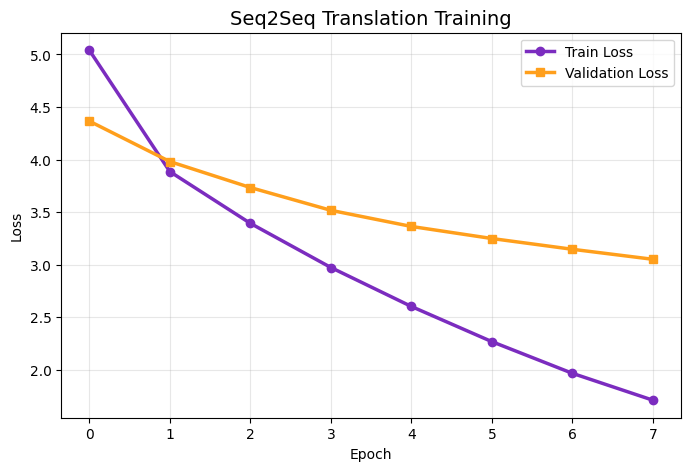

In [39]:
plt.figure(figsize=(8,5))

plt.plot(train_loss_list, marker="o", linewidth=2.5, label="Train Loss", color="#7B2CBF")
plt.plot(val_loss_list, marker="s", linewidth=2.5, label="Validation Loss", color="#FF9F1C")

plt.title("Seq2Seq Translation Training", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Translation

In [43]:
def translate_text(sentence, max_len=20):
    model.eval()

    sentence = clean_text(sentence)
    words = sentence.split()
    ids = [en_vocab.get(w, en_vocab["<unk>"]) for w in words]

    src = torch.tensor(ids, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        hidden, cell = model.encoder(src)

    current = torch.tensor([ru_vocab["<sos>"]], dtype=torch.long).to(device)
    result = []

    for _ in range(max_len):
        with torch.no_grad():
            out, hidden, cell = model.decoder(current, hidden, cell)

        next_id = out.argmax(1).item()

        if next_id == ru_vocab["<eos>"]:
            break

        result.append(ru_rev.get(next_id, "<unk>"))
        current = torch.tensor([next_id], dtype=torch.long).to(device)

    return " ".join(result)

examples = [
    "the boy opened the window",
    "the bird flew to its nest",
    "i am very hungry now",
    "some people think the president travels too much"
]

for s in examples:
    print("EN:", s)
    print("RU:", translate_text(s))
    print("-" * 50)

EN: the boy opened the window
RU: веди дверь
--------------------------------------------------
EN: the bird flew to its nest
RU: будь
--------------------------------------------------
EN: i am very hungry now
RU: я сейчас сейчас
--------------------------------------------------
EN: some people think the president travels too much
RU: открывай немного
--------------------------------------------------
